번역을 위한 트랜스포머

In [1]:
import spacy.cli
spacy.cli.download("de_core_news_sm")
spacy.cli.download("en_core_web_sm")
import torchtext
from torchtext.datasets import multi30k, Multi30k
import torch
from typing import Iterable, List
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu
from torch import Tensor
import torch
import torch.nn as nn
from torch.nn import Transformer
import math
from tqdm import tqdm

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
#wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0205EN-SkillsNetwork/Multi30K_de_en_dataloader.py'
#wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0201EN-Coursera/transformer.pt'
#wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0201EN-Coursera/input_de.pdf'

In [3]:
# Define special symbols and indices
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
# Make sure the tokens are in order of their indices to properly insert them in vocab
special_symbols = ['<unk>', '<pad>', '<bos>', '<eos>']

In [5]:
train_dataloader, _ = get_translation_dataloaders(batch_size = 1)

NameError: name 'get_translation_dataloaders' is not defined

In [6]:
data_itr=iter(train_dataloader)
data_itr

NameError: name 'train_dataloader' is not defined

In [7]:
for n in range(1000):
    german, english= next(data_itr)

NameError: name 'data_itr' is not defined

In [8]:
german=german.T
english=english.T

NameError: name 'german' is not defined

In [9]:
for n in range(10):
    german, english= next(data_itr)

    print("sample {}".format(n))
    print("german input")
    print(index_to_german(german))
    print("english target")
    print(index_to_eng(english))
    print("_________\n")

NameError: name 'data_itr' is not defined

In [10]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cpu')

In [11]:
def generate_square_subsequent_mask(sz,device=DEVICE):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_mask(src, tgt,device=DEVICE):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len),device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

# Add positional information to the input tokens
class PositionalEncoding(nn.Module):
    def __init__(self,
                 emb_size: int,
                 dropout: float,
                 maxlen: int = 5000):
        super(PositionalEncoding, self).__init__()
        den = torch.exp(- torch.arange(0, emb_size, 2)* math.log(10000) / emb_size)
        pos = torch.arange(0, maxlen).reshape(maxlen, 1)
        pos_embedding = torch.zeros((maxlen, emb_size))
        pos_embedding[:, 0::2] = torch.sin(pos * den)
        pos_embedding[:, 1::2] = torch.cos(pos * den)
        pos_embedding = pos_embedding.unsqueeze(-2)

        self.dropout = nn.Dropout(dropout)
        self.register_buffer('pos_embedding', pos_embedding)

    def forward(self, token_embedding: Tensor):
        return self.dropout(token_embedding + self.pos_embedding[:token_embedding.size(0), :])
    

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size: int, emb_size):
        super(TokenEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens: Tensor):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)

In [12]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self,
                 num_encoder_layers: int,
                 num_decoder_layers: int,
                 emb_size: int,
                 nhead: int,
                 src_vocab_size: int,
                 tgt_vocab_size: int,
                 dim_feedforward: int = 512,
                 dropout: float = 0.1):
        super(Seq2SeqTransformer, self).__init__()

        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            emb_size, dropout=dropout)
        self.transformer = Transformer(d_model=emb_size,
                                       nhead=nhead,
                                       num_encoder_layers=num_encoder_layers,
                                       num_decoder_layers=num_decoder_layers,
                                       dim_feedforward=dim_feedforward,
                                       dropout=dropout)
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(self,
                src: Tensor,
                trg: Tensor,
                src_mask: Tensor,
                tgt_mask: Tensor,
                src_padding_mask: Tensor,
                tgt_padding_mask: Tensor,
                memory_key_padding_mask: Tensor):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(src_emb, tgt_emb, src_mask, tgt_mask, None,
                                src_padding_mask, tgt_padding_mask, memory_key_padding_mask)
        outs =outs.to(DEVICE)
        return self.generator(outs)

    def encode(self, src: Tensor, src_mask: Tensor):
        return self.transformer.encoder(self.positional_encoding(
                            self.src_tok_emb(src)), src_mask)

    def decode(self, tgt: Tensor, memory: Tensor, tgt_mask: Tensor):
        return self.transformer.decoder(self.positional_encoding(
                          self.tgt_tok_emb(tgt)), memory,
                          tgt_mask)

In [13]:
torch.manual_seed(0)

SRC_LANGUAGE = 'de'
TGT_LANGUAGE = 'en'
SRC_VOCAB_SIZE = len(vocab_transform[SRC_LANGUAGE])
TGT_VOCAB_SIZE = len(vocab_transform[TGT_LANGUAGE])
EMB_SIZE = 512
NHEAD = 8
FFN_HID_DIM = 512
BATCH_SIZE = 128
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3

transformer = Seq2SeqTransformer(NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, EMB_SIZE,
                                 NHEAD, SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, FFN_HID_DIM)

for p in transformer.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

transformer = transformer.to(DEVICE)

NameError: name 'vocab_transform' is not defined

In [14]:
transformer.load_state_dict(torch.load('transformer.pt', map_location=DEVICE, ))

NameError: name 'transformer' is not defined

In [15]:
for n in range(100):
    src ,tgt= next(data_itr)

NameError: name 'data_itr' is not defined

In [16]:
print("engish target",index_to_eng(tgt))
print("german input",index_to_german(src))

NameError: name 'index_to_eng' is not defined

In [17]:
num_tokens = src.shape[0]
num_tokens

NameError: name 'src' is not defined

In [18]:
src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool).to(DEVICE )
src_mask[0:10]

NameError: name 'num_tokens' is not defined

In [19]:
src_=src[:,0].unsqueeze(1)
print(src_.shape)
print(src.shape)

NameError: name 'src' is not defined

In [20]:
memory = transformer.encode(src_, src_mask)
memory.shape

NameError: name 'transformer' is not defined

In [21]:
ys = torch.ones(1, 1).fill_(BOS_IDX).type(torch.long).to(DEVICE)
ys

tensor([[2]])

In [22]:
tgt_mask = (generate_square_subsequent_mask(ys.size(0)).type(torch.bool)).to(DEVICE)
tgt_mask

tensor([[False]])

In [23]:
out = transformer.decode(ys, memory, tgt_mask)
out.shape

NameError: name 'transformer' is not defined

In [24]:
out = out.transpose(0, 1)
out.shape

NameError: name 'out' is not defined

In [25]:
logit = transformer.generator(out[:, -1])
logit.shape

NameError: name 'transformer' is not defined

In [26]:
_, next_word_index = torch.max(logit, dim=1)
print("engish output:",index_to_eng(next_word_index))

NameError: name 'logit' is not defined

In [27]:
next_word_index=next_word_index.item()
next_word_index

NameError: name 'next_word_index' is not defined

In [28]:
ys = torch.cat([ys,torch.ones(1, 1).type_as(src.data).fill_(next_word_index)], dim=0)
ys

NameError: name 'src' is not defined

In [29]:
# Update the target mask for the current sequence length.
tgt_mask = (generate_square_subsequent_mask(ys.size(0)).type(torch.bool)).to(DEVICE)
tgt_mask

tensor([[False]])

In [30]:
# Decode the current sequence using the transformer and retrieve the output.
out = transformer.decode(ys, memory, tgt_mask)
out = out.transpose(0, 1)
out.shape

NameError: name 'transformer' is not defined

In [31]:
out[:, -1].shape

NameError: name 'out' is not defined

In [32]:
# Get the word probabilities for the last predicted word.
prob = transformer.generator(out[:, -1])
# Find the word index with the highest probability.
_, next_word_index = torch.max(prob, dim=1)
# Print the predicted English word.
print("English output:", index_to_eng(next_word_index))
# Convert the tensor value to a Python scalar.
next_word_index = next_word_index.item()

NameError: name 'transformer' is not defined

In [33]:
ys = torch.cat([ys,torch.ones(1, 1).type_as(src.data).fill_(next_word_index)], dim=0)
print("engish output",index_to_eng(ys))

NameError: name 'src' is not defined

In [34]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    src = src.to(DEVICE)
    src_mask = src_mask.to(DEVICE)

    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len-1):
        memory = memory.to(DEVICE)
        tgt_mask = (generate_square_subsequent_mask(ys.size(0))
                    .type(torch.bool)).to(DEVICE)
        out = model.decode(ys, memory, tgt_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat([ys,
                        torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=0)
        if next_word == EOS_IDX:
            break
    return ys

In [35]:
src
src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool).to(DEVICE )

NameError: name 'src' is not defined

In [36]:
max_len=src.shape[0]+5
max_len

NameError: name 'src' is not defined

In [37]:
ys=greedy_decode(transformer, src, src_mask, max_len, start_symbol=BOS_IDX)
print("engish ",index_to_eng(ys))

NameError: name 'transformer' is not defined

In [38]:
print("engish ",index_to_eng(tgt))

NameError: name 'index_to_eng' is not defined

In [39]:
from torch.nn import CrossEntropyLoss

loss_fn = CrossEntropyLoss(ignore_index=PAD_IDX)

In [40]:
tgt_input = tgt[:-1, :]
print(index_to_eng(tgt_input))
print(index_to_eng(tgt))

NameError: name 'tgt' is not defined

In [41]:
src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)
print(f"Shape of src_mask: {src_mask.shape}")
print(f"Shape of tgt_mask: {tgt_mask.shape}")
print(f"Shape of src_padding_mask: {src_padding_mask.shape}")
print(f"Shape of tgt_padding_mask: {tgt_padding_mask.shape}")

NameError: name 'src' is not defined

In [42]:
src_padding_mask

NameError: name 'src_padding_mask' is not defined

In [43]:
print(tgt_mask)
[index_to_eng( tgt_input[t==0])  for t in tgt_mask] #index_to_eng(tgt_input))

tensor([[False]])


NameError: name 'index_to_eng' is not defined

In [44]:
logits = transformer(src, tgt_input, src_mask, tgt_mask,src_padding_mask, tgt_padding_mask, src_padding_mask)

print("output shape",logits.shape)
print("target shape",tgt_input.shape)
print("source shape ",src.shape)

NameError: name 'transformer' is not defined

In [45]:
tgt_out = tgt[1:, :]
print(tgt_out.shape)
[index_to_eng(t)  for t in tgt_out]

NameError: name 'tgt' is not defined

In [46]:
tgt_out_flattened = tgt_out.reshape(-1)
print(tgt_out_flattened.shape)
tgt_out_flattened

NameError: name 'tgt_out' is not defined

In [48]:
["input: {} target: {}".format(index_to_eng( tgt_input[m==0]),index_to_eng( t))  for m,t in zip(tgt_mask,tgt_out)] 

NameError: name 'tgt_out' is not defined

In [49]:
loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
print(loss)

NameError: name 'logits' is not defined

In [50]:
# logits.reshape(-1, logits.shape[-1]) reshapes the logits tensor to a 2D tensor with a shape of [sequence_length * batch_size, vocab_size]. This reshaping is done to align both the predicted logits and target outputs for the loss calculation.
print("logit's shape is:",logits.shape)
logits_flattened = logits.reshape(-1, logits.shape[-1])
print("logit_flat's shape is:",logits_flattened.shape)


# tgt_out.reshape(-1) reshapes the tgt_out tensor to a 1D tensor by flattening it along the sequence and batch dimensions. This is done to align it with the reshaped logits.
print("tgt_out's shape is:",tgt_out.shape)
tgt_out_flattened = tgt_out.reshape(-1)
print("tgt_out_flat's shape is:",tgt_out_flattened.shape)


NameError: name 'logits' is not defined

In [51]:
# Applying the Cross-Entropy Loss Function
probs = torch.nn.functional.softmax(logits_flattened, dim=1)
probs[1].sum()

NameError: name 'logits_flattened' is not defined

In [52]:
for i in range (5):
    # using argmax, you can retrieve the index of the token that is predicted with the highest probaility
    print("Predicted token id:",probs[i].argmax().item(), "predicted probaility:",probs[i].max().item())
    # you can also check the actual token from the tgt_out_flat
    print("Actual token id:",tgt_out_flattened[i].item(), "predicted probaility:", probs[i,tgt_out_flattened[i]].item(),"\n")

NameError: name 'probs' is not defined

In [53]:
neg_log_likelihood = torch.nn.functional.nll_loss(probs, tgt_out_flattened)
# Step 3: Obtaining the Loss Value
loss = neg_log_likelihood

# Print the total loss value
print("Loss:", loss.item())

NameError: name 'probs' is not defined

In [54]:
def evaluate(model):
    model.eval()
    losses = 0



    for src, tgt in val_dataloader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        tgt_input = tgt[:-1, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)
        logits = model(src, tgt_input, src_mask, tgt_mask,src_padding_mask, tgt_padding_mask, src_padding_mask)

        tgt_out = tgt[1:, :]
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        losses += loss.item()

    return losses / len(list(val_dataloader))

In [55]:
def train_epoch(model, optimizer, train_dataloader):
    model.train()
    losses = 0

    # Wrap train_dataloader with tqdm for progress logging
    train_iterator = tqdm(train_dataloader, desc="Training", leave=False)

    for src, tgt in train_iterator:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        tgt_input = tgt[:-1, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)
        src_mask = src_mask.to(DEVICE)
        tgt_mask = tgt_mask.to(DEVICE)
        src_padding_mask = src_padding_mask.to(DEVICE)
        tgt_padding_mask = tgt_padding_mask.to(DEVICE)

        logits = model(src, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, src_padding_mask)
        logits = logits.to(DEVICE)

        optimizer.zero_grad()

        tgt_out = tgt[1:, :]
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        loss.backward()

        optimizer.step()
        losses += loss.item()

        # Update tqdm progress bar with the current loss
        train_iterator.set_postfix(loss=loss.item())

    return losses / len(list(train_dataloader))

In [56]:
torch.manual_seed(0)

SRC_VOCAB_SIZE = len(vocab_transform[SRC_LANGUAGE])
TGT_VOCAB_SIZE = len(vocab_transform[TGT_LANGUAGE])
EMB_SIZE = 512
NHEAD = 8
FFN_HID_DIM = 512
BATCH_SIZE = 128
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3

NameError: name 'vocab_transform' is not defined

In [57]:
train_dataloader, val_dataloader = get_translation_dataloaders(batch_size = BATCH_SIZE)

NameError: name 'get_translation_dataloaders' is not defined

In [58]:
transformer = Seq2SeqTransformer(NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, EMB_SIZE,
                                 NHEAD, SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, FFN_HID_DIM)
transformer = transformer.to(DEVICE)

NameError: name 'NUM_ENCODER_LAYERS' is not defined

In [59]:
optimizer = torch.optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

NameError: name 'transformer' is not defined

In [60]:
TrainLoss=[]
ValLoss=[]

In [61]:
from timeit import default_timer as timer
NUM_EPOCHS = 10

for epoch in range(1, NUM_EPOCHS+1):
    start_time = timer()
    train_loss = train_epoch(transformer, optimizer, train_dataloader)
    TrainLoss.append(train_loss)
    end_time = timer()
    val_loss = evaluate(transformer)
    ValLoss.append(val_loss)
    print((f"Epoch: {epoch}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}, "f"Epoch time = {(end_time - start_time):.3f}s"))
torch.save(transformer.state_dict(), 'transformer_de_to_en_model.pt')

NameError: name 'transformer' is not defined

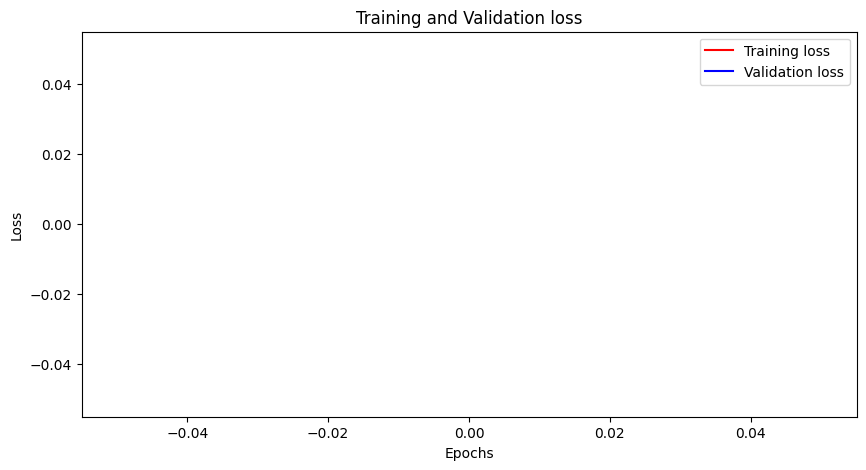

In [62]:
epochs = range(1, len(TrainLoss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, TrainLoss, 'r', label='Training loss')
plt.plot(epochs,ValLoss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [63]:
#!wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0201EN-Coursera/transformer_de_to_en_model.pt'
#transformer.load_state_dict(torch.load('transformer_de_to_en_model.pt',map_location=torch.device('cpu')))

In [64]:
# translate input sentence into target language
def translate(model: torch.nn.Module, src_sentence: str):
    model.eval()
    src = text_transform[SRC_LANGUAGE](src_sentence).view(-1, 1)
    num_tokens = src.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model,  src, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX).flatten()
    return " ".join(vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))).replace("<bos>", "").replace("<eos>", "")

In [65]:
for n in range(5):
    german, english= next(data_itr)

    print("German Sentence:",index_to_german(german).replace("<bos>", "").replace("<eos>", ""))
    print("English Translation:",index_to_eng(english).replace("<bos>", "").replace("<eos>", ""))
    print("Model Translation:",translate(transformer,index_to_german(german)))
    print("_________\n")

NameError: name 'data_itr' is not defined

In [66]:
def calculate_bleu_score(generated_translation, reference_translations):
    # convert the generated translations and reference translations into the expected format for sentence_bleu
    references = [reference.split() for reference in reference_translations]
    hypothesis = generated_translation.split()

    # calculate the BLEU score
    bleu_score = sentence_bleu(references, hypothesis)

    return bleu_score

In [67]:
generated_translation = translate(transformer,"Ein brauner Hund spielt im Schnee .")

reference_translations = [
    "A brown dog is playing in the snow .",
    "A brown dog plays in the snow .",
    "A brown dog is frolicking in the snow .",
    "In the snow, a brown dog is playing ."

]

bleu_score = calculate_bleu_score(generated_translation, reference_translations)
print("BLEU Score:", bleu_score, "for",generated_translation)

NameError: name 'transformer' is not defined

In [68]:
def translate_pdf(input_file, translator_model,output_file):
    translated_text = ""

    # Read the input PDF file
    with pdfplumber.open(input_file) as pdf:


        # Extract text from each page of the PDF
        for page in pdf.pages:
            text_content = page.extract_text()
            num_pages = len(pdf.pages)
            a4_width_mm = 210
            pt_to_mm = 0.35
            fontsize_pt = 10
            fontsize_mm = fontsize_pt * pt_to_mm
            margin_bottom_mm = 10
            character_width_mm = 7 * pt_to_mm
            width_text = a4_width_mm / character_width_mm

            pdf = FPDF(orientation='P', unit='mm', format='A4')
            pdf.set_auto_page_break(True, margin=margin_bottom_mm)
            pdf.add_page()
            pdf.set_font(family='Courier', size=fontsize_pt)
            # Split the text into sentences
            sentences = text_content.split(".")

            # Translate each sentence using the custom translator model
            for sentence in sentences:
                translated_sentence = translate(translator_model,sentence)
                lines = textwrap.wrap(translated_sentence, width_text)

                if len(lines) == 0:
                    pdf.ln()

                for wrap in lines:
                    pdf.cell(0, fontsize_mm, wrap, ln=1)

            pdf.output(output_file, 'F')

In [69]:
#wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0201EN-Coursera/input_de.pdf'

In [71]:
input_file_path = "input_de.pdf"
output_file = 'output_en.pdf'
translate_pdf(input_file_path, transformer,output_file)
print("Translated PDF file is saved as:", output_file)

NameError: name 'transformer' is not defined